### Bande parabolique

Dans cette partie on test rapidement le schéma pour une bande de dispersion parabolique $\varepsilon(p) = \dfrac {\alpha p^2}{2}$.
On devrait alors retrouver des trajectoires sphériques dans l'espace des moments.

Calculons aussi la solution théorique:
En posant $G:=\dfrac{eB}{c}$ le problème de départ est : 
$$

\begin{cases}
p_x'(t) = G \left( \alpha p_y + v_d \right) \\
p_y'(t) = - G \alpha p_x
\end{cases}
$$
En dérivant la première ligne et en remplaçant $p_y'(t)$, on obtient:
$$ p_x''(t) + (G \times alpha)^2 \times p_x(t) = 0$$
D'où 
$$p_x(t) = A \cos(G \alpha t) + B \sin(G \alpha t)$$
avec A et B deux réels.
On suppose que au temps initial $P = (1, 0)$, alors $p_x(0) \Longrightarrow A = 1 $.

On repart ensuite de $p_y'(t)$ et on intègre par rapport à t on utilisant la forme de $p_x(t)$ obtenue on a:
$$
p_y(t) = \sin(G \alpha t) + B \cos(G \alpha t) + cst
$$ 
On en profite pour remarquer que comme $p_y(0) = 0$ on a : $B + cst = 0 $.

En utilisant la forme initial de $p_x'(t)$ et la forme obtenue en dérivant l'écriture avec le cosinus et le sinus puis en évaluant en 0 on trouve:
$$
\begin{aligned}
B G \alpha &= G v_d \\
B &= \dfrac{v_d}{alpha}
\end{aligned}
$$
et donc $cst = -\dfrac{v_d}{alpha}$.
On ainsi trouvé comme solution:
$$
\begin{cases}
p_x(t) = \cos(G \alpha t) + \dfrac{v_d}{alpha} \sin(G \alpha t) \\
p_y(t) = \dfrac{v_d}{\alpha}\cos(G \alpha t) - \dfrac{1}{alpha}\sin(G \alpha t) - \dfrac{v_d}{alpha}
\end{cases}
$$


En redérivant on retrouve bien le problème de départ, la solution est correct.

In [1]:
# Packages ------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pyhamsys import HamSys, solve_ivp_sympext, Parameters

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  1 


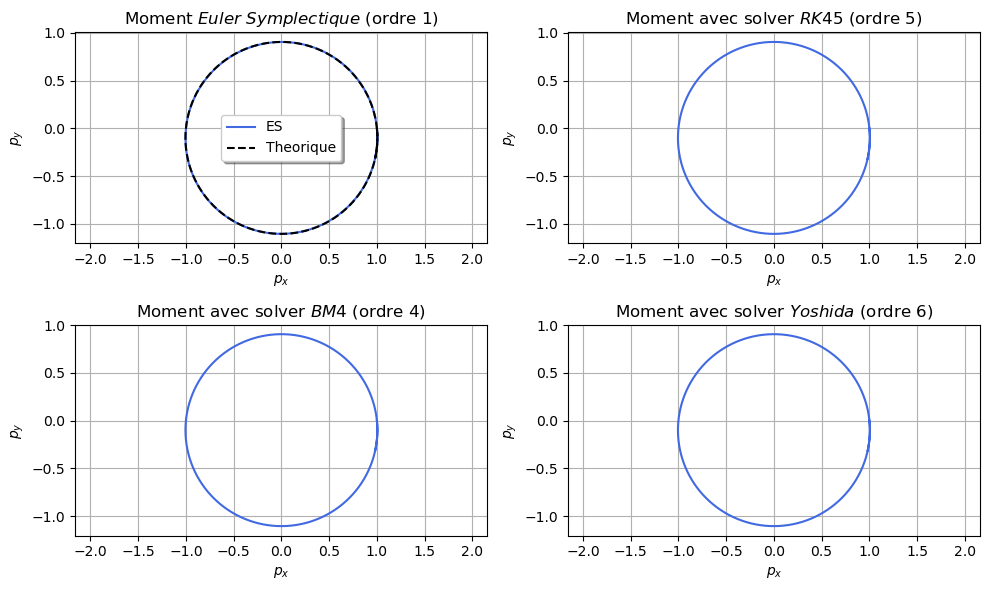

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  5 


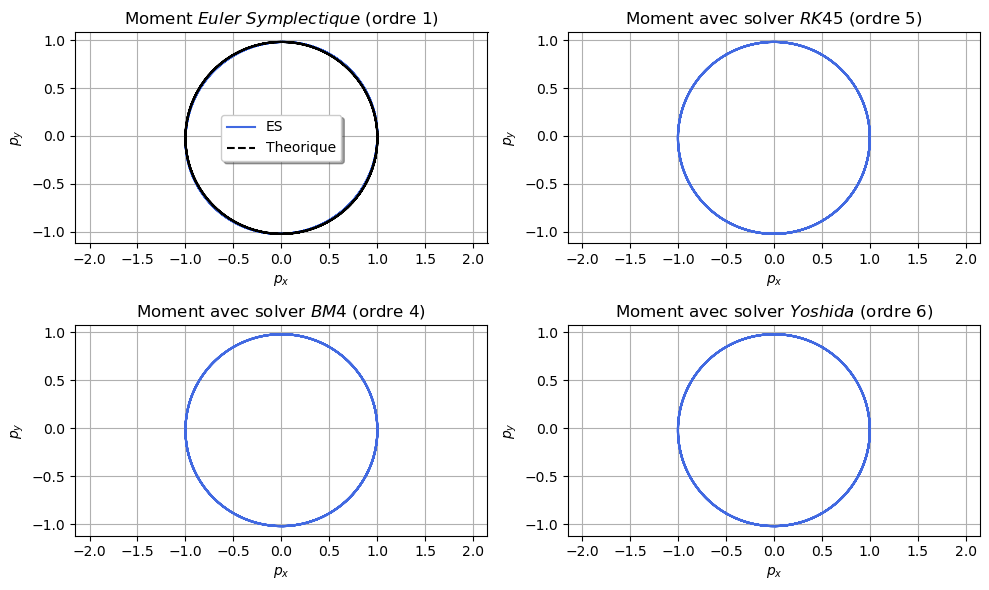

        Computation finished in 0 seconds


Comparaison des méthodes avec alpha =  10 


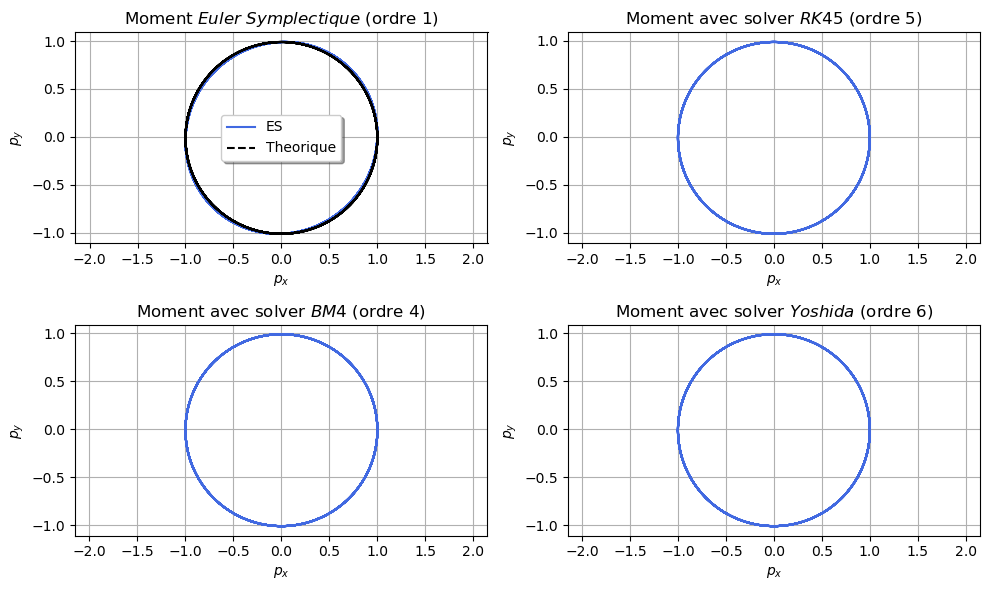

In [4]:
deltaT = 0.01
T = 3* np.pi
time_range = np.arange(0, T + deltaT , deltaT) #On dépasse un peu le temps final.
P = np.array([1, 0])
e = 1
B = 0.7
vF = 1
c = 1
vd = 0.1 #5.0
alpha_liste = [ 1, 5, 10]

# def varepsilon_parabolique(p, alpha):
#     px = p[0]
#     py = p[1]
    
#     return  alpha * (px**2 + py**2) / 2

def ES_parabolique(deltaT, T, P, e , B, c, alpha):
    G = deltaT * e * B * alpha / c
    Iteration_matrix = [[1 - G**2, G], [-G, 1]]
    Drift_matrix = [deltaT * e * B * vd /c, 0]
    P_trajectory = [P]
    t = 0
    while ( t + deltaT < T):
        P = Iteration_matrix @ P + Drift_matrix
        t += deltaT
        P_trajectory.append(P)
    deltaT = T - t
    Drift_matrix = [deltaT * e * B * vd /c, 0] 
    P = Iteration_matrix @ P + Drift_matrix
    return np.array(P_trajectory)
   
def p_system(t, P): #resolution papier pour bande parabolique
    G =  e * B  / c
    return np.array( [G * (alpha * P[1] + vd)  , -G * alpha * P[0] ])
# ----------------------------------------------------------------------------------------------
# Ajout de la solution théorique
def theo_para(time_range, alpha):
    G = e * B / c

    px = np.cos(G * alpha * time_range) + vd / alpha * np.sin(G * alpha * time_range)
    py = vd / alpha * np.cos(G * alpha * time_range) - np.sin(G * alpha * time_range)  - vd / alpha

    return px, py

#---------------------------------------------------------------------------------------------------
hs = HamSys(ndof=1)
for i, alpha in enumerate(alpha_liste):
    hs.y_dot = p_system # choix du système
    sol_BM4 = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='BM4'))
    # sol_Verlet = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Verlet'))
    sol_Yoshida = solve_ivp_sympext(hs, t_span=(0,T), y0=P, params=Parameters(step=deltaT, solver='Yos6'))

    Moment_ES = ES_parabolique(deltaT, T, P, e, B, c, alpha)

    sol_RK45 = hs.integrate( P, time_range, params=Parameters(step=deltaT, solver='RK45'))

    sol_theorique = theo_para(time_range, alpha)
# Plot -------------------------------------------------------------------------------------------------

    print(f'Comparaison des méthodes avec alpha =  {alpha} ')
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,6))

    ax1.plot(Moment_ES[:, 0], Moment_ES[:,1], color='royalblue',label='ES')
    ax1.set_xlabel(r'$p_x$')
    ax1.set_ylabel(r'$p_y$')
    ax1.set_title(r'Moment $Euler \ Symplectique$ (ordre 1)')  
    
    ax1.plot(sol_theorique[ 0], sol_theorique[1], linestyle='--', color='black',label='Theorique')  
    ax1.legend(shadow=True)
    # ax1.plot(sol_Verlet.y[0], sol_Verlet.y[1], color='royalblue',label='ES')
    # ax1.set_xlabel(r'$p_x$')
    # ax1.set_ylabel(r'$p_y$')
    # ax1.set_title(r'Moment solver $Verlet$ (ordre 2)') 


    ax2.plot(sol_RK45.y[0], sol_RK45.y[1], color='royalblue')
    ax2.set_xlabel(r'$p_x$')
    ax2.set_ylabel(r'$p_y$')
    ax2.set_title(r'Moment avec solver $RK45$ (ordre 5)')

    ax3.plot(sol_BM4.y[0], sol_BM4.y[1], color='royalblue')
    ax3.set_xlabel(r'$p_x$')
    ax3.set_ylabel(r'$p_y$')
    ax3.set_title(r'Moment avec solver $BM4$ (ordre 4)')

    ax4.plot(sol_Yoshida.y[0], sol_Yoshida.y[1], color='royalblue')
    ax4.set_xlabel(r'$p_x$')
    ax4.set_ylabel(r'$p_y$')
    ax4.set_title(r'Moment avec solver $Yoshida$ (ordre 6)')
    ax1.grid(), ax2.grid(), ax3.grid(), ax4.grid()
    ax1.axis('equal'), ax2.axis('equal'), ax3.axis('equal'), ax4.axis('equal')

    plt.tight_layout()
    plt.show()